# 40 — Build the daily changing desk portfolio

Create the frozen prior-day portfolios required for PLA and backtesting.

The same 48 trades remain the foundation, but their sizes change through documented resizing and hedge adjustments. The final date is anchored to the current book, and fixed seeds make every snapshot reproducible.

This step uses: The shared trading book and 501 position dates, which produce 500 next-day P&L outcomes.

It produces: A date–trade–desk position snapshot with an explicit event reason.

> Basel norm applied: MAR32 testing uses daily desk outcomes based on the portfolio held at the relevant date.

$$P_t=\{q_{1,t},q_{2,t},\ldots,q_{48,t}\}$$

Synthetic inputs are labelled directly in the displayed data. Basel regulatory parameters are loaded separately from versioned configuration.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from frtb_engine.notebook_tools import INR_CRORE, configure_notebooks, crore_table, draw_flow, heatmap

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_ima_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
MANIFEST = json.loads((RUN / 'run_manifest.json').read_text(encoding='utf-8'))
STAGES = {row['stage']: ROOT / row['path'] for row in MANIFEST['artifacts']}
SUMMARY = json.loads((RUN / '27_combined_capital_summary.json').read_text(encoding='utf-8'))

def stage(name):
    return pd.read_csv(STAGES[name])

def money(value):
    return f"INR {float(value) / INR_CRORE:,.2f} crore"

print(f'IMA calculation run used: {RUN_ID}')
print('Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled')

IMA calculation run used: IMA_20260908T033903126517Z
Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled


In [2]:
snap=stage('18_portfolio_snapshots'); snap['date']=pd.to_datetime(snap.date)
print(f"{snap.trade_id.nunique()} shared trades across {snap.date.nunique()} business dates produce {len(snap):,} stored position rows.")
changed=snap[snap.position_event!='UNCHANGED']
print(f'Displayed sample: first 20 of {len(changed):,} rows containing a documented position event.')
display(changed.head(20))
example=snap[snap.trade_id=='R09'].sort_values('date'); print('The position multiplier changes the size of the same underlying trade; it does not create a different portfolio universe.')

48 shared trades across 501 business dates produce 24,048 stored position rows.
Displayed sample: first 20 of 588 rows containing a documented position event.


,date,trade_id,desk,instrument_type,position_multiplier,position_event,notional_or_quantity_scale,data_status
34,2024-09-16,R01,Rates,BOND,0.9000,POSITION_RESIZED,0.9000,SYNTHETIC_SYSTEMATIC_PORTFOLIO_HISTORY
97,2024-12-12,R01,Rates,BOND,0.9900,POSITION_RESIZED,0.9900,SYNTHETIC_SYSTEMATIC_PORTFOLIO_HISTORY
160,2025-03-11,R01,Rates,BOND,1.1880,POSITION_RESIZED,1.1880,SYNTHETIC_SYSTEMATIC_PORTFOLIO_HISTORY
223,2025-06-06,R01,Rates,BOND,1.3068,POSITION_RESIZED,1.3068,SYNTHETIC_SYSTEMATIC_PORTFOLIO_HISTORY
286,2025-09-03,R01,Rates,BOND,1.4375,POSITION_RESIZED,1.4375,SYNTHETIC_SYSTEMATIC_PORTFOLIO_HISTORY
349,2025-12-01,R01,Rates,BOND,1.5812,POSITION_RESIZED,1.5812,SYNTHETIC_SYSTEMATIC_PORTFOLIO_HISTORY
412,2026-02-26,R01,Rates,BOND,1.4231,POSITION_RESIZED,1.4231,SYNTHETIC_SYSTEMATIC_PORTFOLIO_HISTORY
475,2026-05-26,R01,Rates,BOND,1.5654,POSITION_RESIZED,1.5654,SYNTHETIC_SYSTEMATIC_PORTFOLIO_HISTORY
500,2026-06-30,R01,Rates,BOND,1.0000,CURRENT_BOOK_ANCHOR,1.0000,SYNTHETIC_SYSTEMATIC_PORTFOLIO_HISTORY
520,2024-08-26,R02,Rates,BOND,1.1000,POSITION_RESIZED,1.1000,SYNTHETIC_SYSTEMATIC_PORTFOLIO_HISTORY


The position multiplier changes the size of the same underlying trade; it does not create a different portfolio universe.


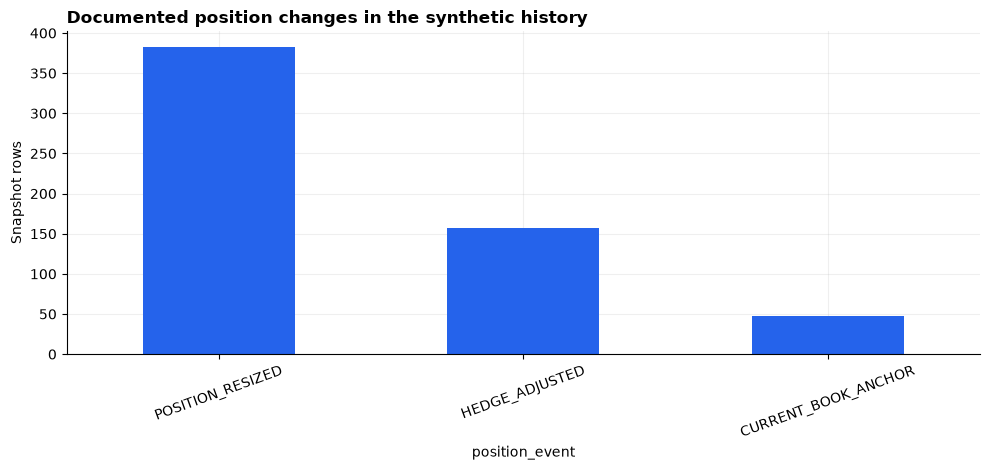

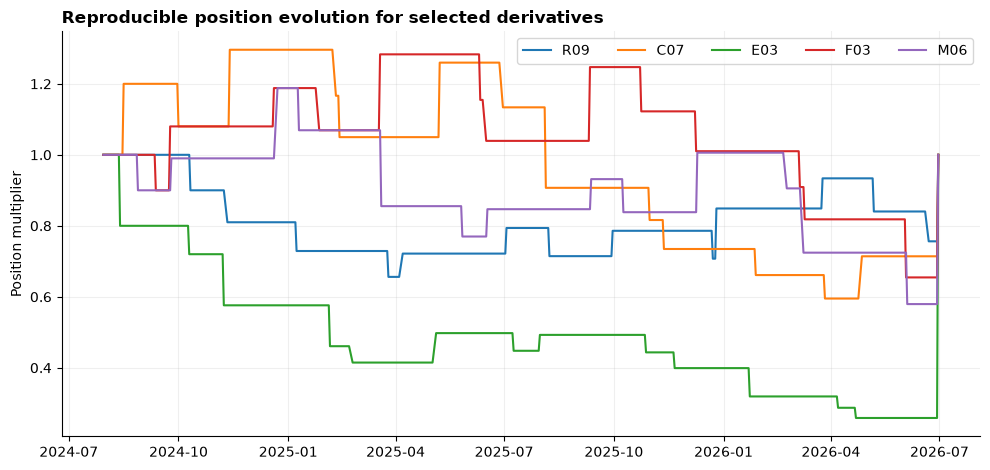

In [3]:
events=snap[snap.position_event!='UNCHANGED'].position_event.value_counts(); ax=events.plot(kind='bar',color='#2563EB'); ax.set_ylabel('Snapshot rows'); ax.set_title('Documented position changes in the synthetic history',loc='left',weight='bold'); ax.tick_params(axis='x',rotation=20); plt.tight_layout(); plt.show()
fig,ax=plt.subplots();
for trade in ['R09','C07','E03','F03','M06']:
 g=snap[snap.trade_id==trade]; ax.plot(g.date,g.position_multiplier,label=trade)
ax.set_ylabel('Position multiplier'); ax.set_title('Reproducible position evolution for selected derivatives',loc='left',weight='bold'); ax.legend(ncol=5); plt.tight_layout(); plt.show()

The first chart counts each documented type of synthetic position change across the 501 position dates. It explains how often resizing, hedge adjustment and the final current-book anchor occur. The second chart follows five selected trades through time: a multiplier of 1 is the current size, values above 1 are larger historical positions and values below 1 are reductions.